In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import pandas as pd

# Kidney Cancer Data Analysis

This is an example on "Bayesian Disease Mapping", and is taken from Section 2.7 on estimation of kidney cancer rates of the book "Bayesian Data Analysis Edition 3" by Gelman et al. Some of the code is taken from a blog post by Robin Ryder (google this).   

In [2]:
#Read the kidney cancer dataset
d_full = pd.read_csv("KidneyCancerClean.csv", skiprows=4)
display(d_full.head(15))
summary = d_full.describe(include = 'all')
display(summary)

,Unnamed: 0,state,Location,fips,dc,dcV,pop,popV,aadc,aadcV,...,good,dc.2,dcV.2,pop.2,popV.2,aadc.2,aadcV.2,dcC.2,dcCV.2,good.2
0,108,ALABAMA,"Autauga County, Alabama",1001,2,VALID,61921,VALID,3.3,UNRELIABLE,...,1,1,VALID,64915,VALID,1.7,UNRELIABLE,1.5,UNRELIABLE,1
1,117,ALABAMA,"Baldwin County, Alabama",1003,7,VALID,170945,VALID,3.5,UNRELIABLE,...,1,15,VALID,195253,VALID,6.3,UNRELIABLE,7.7,UNRELIABLE,1
2,129,ALABAMA,"Barbour County, Alabama",1005,0,VALID,33316,VALID,0.0,UNRELIABLE,...,1,1,VALID,33987,VALID,2.6,UNRELIABLE,2.9,UNRELIABLE,1
3,199,ALABAMA,"Bibb County, Alabama",1007,0,VALID,30152,VALID,0.0,UNRELIABLE,...,1,1,VALID,31175,VALID,2.9,UNRELIABLE,3.2,UNRELIABLE,1
4,219,ALABAMA,"Blount County, Alabama",1009,3,VALID,88342,VALID,3.2,UNRELIABLE,...,1,5,VALID,91547,VALID,4.8,UNRELIABLE,5.5,UNRELIABLE,1
5,306,ALABAMA,"Bullock County, Alabama",1011,0,VALID,8313,VALID,0.0,UNRELIABLE,...,1,0,VALID,8197,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1
6,318,ALABAMA,"Butler County, Alabama",1013,0,VALID,31963,VALID,0.0,UNRELIABLE,...,1,1,VALID,31722,VALID,2.8,UNRELIABLE,3.2,UNRELIABLE,1
7,343,ALABAMA,"Calhoun County, Alabama",1015,9,VALID,243105,VALID,4.0,UNRELIABLE,...,1,12,VALID,233021,VALID,5.4,UNRELIABLE,5.1,UNRELIABLE,1
8,439,ALABAMA,"Chambers County, Alabama",1017,7,VALID,59985,VALID,8.3,UNRELIABLE,...,1,0,VALID,57813,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1
9,467,ALABAMA,"Cherokee County, Alabama",1019,0,VALID,43401,VALID,0.0,UNRELIABLE,...,1,0,VALID,43828,VALID,0.0,UNRELIABLE,0.0,UNRELIABLE,1


,Unnamed: 0,state,Location,fips,dc,dcV,pop,popV,aadc,aadcV,...,good,dc.2,dcV.2,pop.2,popV.2,aadc.2,aadcV.2,dcC.2,dcCV.2,good.2
count,3110.000000,3110,3110,3110.000000,3110.000000,3110,3.110000e+03,3110,3110.000000,3110,...,3110.000000,3110.000000,3110,3.110000e+03,3110,3110.000000,3110,3109.000000,3109,3110.000000
unique,NaN,50,3109,NaN,NaN,1,NaN,1,NaN,2,...,NaN,NaN,1,NaN,1,NaN,3,NaN,2,NaN
top,NaN,TEXAS,"Bedford County, Virginia",NaN,NaN,VALID,NaN,VALID,NaN,UNRELIABLE,...,NaN,NaN,VALID,NaN,VALID,NaN,UNRELIABLE,NaN,UNRELIABLE,NaN
freq,NaN,254,2,NaN,NaN,3110,NaN,3110,NaN,2882,...,NaN,NaN,3110,NaN,3110,NaN,2848,NaN,2848,NaN
mean,1555.500000,NaN,NaN,30672.690675,7.527974,NaN,1.550087e+05,NaN,4.438392,NaN,...,0.985852,8.359164,NaN,1.606611e+05,NaN,4.834244,NaN,5.787359,NaN,0.985852
std,897.923995,NaN,NaN,14980.587745,23.095402,NaN,4.722345e+05,NaN,3.501390,NaN,...,0.118120,23.765728,NaN,4.972750e+05,NaN,3.709540,NaN,5.030156,NaN,0.118120
min,1.000000,NaN,NaN,1001.000000,0.000000,NaN,2.580000e+02,NaN,0.000000,NaN,...,0.000000,0.000000,NaN,2.670000e+02,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,778.250000,NaN,NaN,19041.500000,1.000000,NaN,2.238250e+04,NaN,2.100000,NaN,...,1.000000,1.000000,NaN,2.213000e+04,NaN,2.525000,NaN,2.800000,NaN,1.000000
50%,1555.500000,NaN,NaN,29210.000000,2.000000,NaN,4.762800e+04,NaN,4.300000,NaN,...,1.000000,3.000000,NaN,4.806950e+04,NaN,4.600000,NaN,5.200000,NaN,1.000000
75%,2332.750000,NaN,NaN,46008.500000,6.000000,NaN,1.146262e+05,NaN,6.100000,NaN,...,1.000000,7.000000,NaN,1.179355e+05,NaN,6.600000,NaN,7.700000,NaN,1.000000


This is county-level data on population and deaths due to kidney cancer. There are quite a few columns in the dataset but we shall only work with the four columns: dc, dc.2, pop and pop.2:

1. The columns dc and dc.2 represent death counts due to kidney cancer in 1980-84 and 1985-89 respectively. 
2. The columns pop and pop.2 represent some measure of the average population in 1980-84 and 1985-89 respectively. 

Let us create a smaller dataframe with only these columns. 

In [3]:
d = d_full[['state', 'Location', 'fips', 'dc', 'pop', 'dc.2', 'pop.2']].copy()
display(d.head(20))

,state,Location,fips,dc,pop,dc.2,pop.2
0,ALABAMA,"Autauga County, Alabama",1001,2,61921,1,64915
1,ALABAMA,"Baldwin County, Alabama",1003,7,170945,15,195253
2,ALABAMA,"Barbour County, Alabama",1005,0,33316,1,33987
3,ALABAMA,"Bibb County, Alabama",1007,0,30152,1,31175
4,ALABAMA,"Blount County, Alabama",1009,3,88342,5,91547
5,ALABAMA,"Bullock County, Alabama",1011,0,8313,0,8197
6,ALABAMA,"Butler County, Alabama",1013,0,31963,1,31722
7,ALABAMA,"Calhoun County, Alabama",1015,9,243105,12,233021
8,ALABAMA,"Chambers County, Alabama",1017,7,59985,0,57813
9,ALABAMA,"Cherokee County, Alabama",1019,0,43401,0,43828


The purpose of this data analysis is to estimate the kidney cancer death rates for each county and, more importantly, **to flag the counties with high kidney cancer death rates**. Before proceeding to the analysis, let us first combine the death counts for the two periods 80-84 and 85-89 to get one overall death count for each county. Further, let us take the average of pop and pop.2 to get a measure of the average population of each county in the period 80-89. 

In [4]:
# Combine the death and population counts for the two periods 80-84 and 85-89
d['dct'] = d['dc'] + d['dc.2'] #dct stands for death count total
d['popm'] = (d['pop'] + d['pop.2']) / 2
display(d.head(15))

,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm
0,ALABAMA,"Autauga County, Alabama",1001,2,61921,1,64915,3,63418.0
1,ALABAMA,"Baldwin County, Alabama",1003,7,170945,15,195253,22,183099.0
2,ALABAMA,"Barbour County, Alabama",1005,0,33316,1,33987,1,33651.5
3,ALABAMA,"Bibb County, Alabama",1007,0,30152,1,31175,1,30663.5
4,ALABAMA,"Blount County, Alabama",1009,3,88342,5,91547,8,89944.5
5,ALABAMA,"Bullock County, Alabama",1011,0,8313,0,8197,0,8255.0
6,ALABAMA,"Butler County, Alabama",1013,0,31963,1,31722,1,31842.5
7,ALABAMA,"Calhoun County, Alabama",1015,9,243105,12,233021,21,238063.0
8,ALABAMA,"Chambers County, Alabama",1017,7,59985,0,57813,7,58899.0
9,ALABAMA,"Cherokee County, Alabama",1019,0,43401,0,43828,0,43614.5


A simple way to estimate the kidney cancer rate of each county is to use the proportion: 
\begin{align*}
\text{Naive Estimate of Kidney Cancer Death Rate} =  \frac{\text{Number of Kidney Cancer Deaths}}{\text{Population}}
\end{align*}
We can then rank all the counties according to their naive proportions and flag the counties for whom the naive proportion is high. 

count    3110.000000
mean        0.000108
std         0.000068
min         0.000000
25%         0.000067
50%         0.000100
75%         0.000139
max         0.000691
Name: naiveproportion, dtype: float64


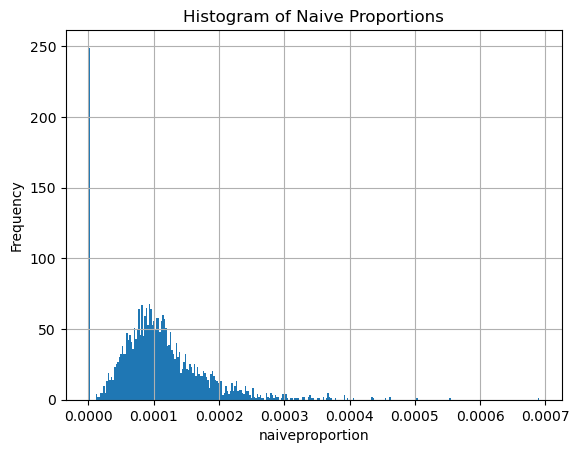

In [5]:
d['naiveproportion'] = d['dct'] / d['popm']
summary = d['naiveproportion'].describe()
print(summary)
#Histogram of naive proportion estimates:
import matplotlib.pyplot as plt
plt.hist(d['naiveproportion'], bins=300)
plt.xlabel('naiveproportion')
plt.ylabel('Frequency')
plt.title('Histogram of Naive Proportions')
plt.grid(True)
plt.show()
#Some observations on the histogram: 
#There is a spike at zero (corresponding to counties with no kidney cancer deaths)
#Most proportions are around 0.0001 but there are a few counties which have large proportions (more than 0.0004)

In [6]:
#Flagging Counties with High Kidney Cancer Death Proportions. 
#One way to do this is to get the counties with the 100 highest naive proportion:
threshold = d['naiveproportion'].nlargest(100).iloc[-1]
print(threshold)

d['cancerhigh'] = d['naiveproportion'] >= threshold
with pd.option_context('display.max_rows', None):
    display(d[d['cancerhigh'] >= True])

0.00025143527636927463


,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm,naiveproportion,cancerhigh
65,ALABAMA,"Wilcox County, Alabama",1131,2,11144,1,10727,3,10935.5,0.000274,True
148,ARKANSAS,"Sharp County, Arkansas",5135,4,34922,5,33806,9,34364.0,0.000262,True
149,ARKANSAS,"Stone County, Arkansas",5137,1,22387,5,23148,6,22767.5,0.000264,True
230,COLORADO,"Dolores County, Colorado",8033,1,4151,1,3797,2,3974.0,0.000503,True
473,GEORGIA,"Quitman County, Georgia",13239,0,2524,1,2557,1,2540.5,0.000394,True
485,GEORGIA,"Talbot County, Georgia",13263,1,5855,1,6008,2,5931.5,0.000337,True
495,GEORGIA,"Treutlen County, Georgia",13283,1,9944,3,9695,4,9819.5,0.000407,True
512,GEORGIA,"Wilkes County, Georgia",13317,3,14334,1,14223,4,14278.5,0.000280,True
535,IDAHO,"Clark County, Idaho",16033,1,2212,0,2176,1,2194.0,0.000456,True
549,IDAHO,"Lewis County, Idaho",16061,2,9705,1,8634,3,9169.5,0.000327,True


In [7]:
#It will be cool to plot the high cancer counties (in terms of the naive proportions) on the US map
#This can be done in the following way.
import plotly.express as px
#First convert fips to standard form:
d['modfips'] = d['fips'].apply(lambda x: str(x).zfill(5))
#Plotting the counties with high cancer proportion:
fig = px.choropleth(
    d, 
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json", # This is a dataset containing county geometries
    locations='modfips', # Use the 'fips' column for county identification
    color='cancerhigh',
    hover_name='Location',  # Display the 'Location' column on hover
    scope="usa",
    title="Top 100 kidney cancer death rate counties (in terms of naive proportions)",
    color_continuous_scale="YlOrRd"
)
fig.update_geos(fitbounds="locations")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Question: Is this a good way of flagging the high kidney cancer rate counties? Should we now look into specific reasons (such as dietary patterns, pollution etc, lack of access to quality medical care etc.) why these  counties have high rates? 

It turns out that this analysis is misleading because of the use of naive proportions as estimates of kidney cancer death rates. In particular, the counties that we flagged are mostly counties with low populations. This can be understood as follows. The typical rate of kidney cancer is about 0.0001 as can be seen, for example, from the naive proportion estimates of counties with large populations. 

In [8]:
sorted_populations = d['popm'].sort_values()
print(list(sorted_populations))
#Select counties with large populations
#By large population, let us take populations more than 300000
largecounties = d[d['popm'] >= 300000]
largecounties.shape[0]
#So there are 323 counties with population more than 300000
#Let us evaluate the naive proportions for these counties. 
summary = d[d['popm'] >= 300000]['naiveproportion'].describe()
display(summary)
#the mean and median are about 0.0001 which can therefore be viewed as a typical value of the kidney cancer rate

[262.5, 978.0, 1017.0, 1139.0, 1233.5, 1268.0, 1297.0, 1448.0, 1570.5, 1594.0, 1640.5, 1862.5, 1879.0, 1942.0, 1946.5, 2058.5, 2108.0, 2160.5, 2171.0, 2175.5, 2194.0, 2250.0, 2296.0, 2337.0, 2342.5, 2353.0, 2358.5, 2473.5, 2522.5, 2540.5, 2542.5, 2547.5, 2570.5, 2731.0, 2731.5, 2817.5, 2866.5, 3005.5, 3027.0, 3095.0, 3102.5, 3268.5, 3294.5, 3305.0, 3433.0, 3434.0, 3532.5, 3556.5, 3583.0, 3596.5, 3616.0, 3629.0, 3819.0, 3974.0, 4044.5, 4076.0, 4129.0, 4182.0, 4188.5, 4224.0, 4341.5, 4342.5, 4349.0, 4351.0, 4448.5, 4449.5, 4450.0, 4465.0, 4487.0, 4493.5, 4518.5, 4527.5, 4571.5, 4600.5, 4632.5, 4695.5, 4715.5, 4784.5, 4832.0, 4836.5, 4952.0, 4956.5, 5169.0, 5177.5, 5236.0, 5256.5, 5268.0, 5282.0, 5284.5, 5309.5, 5311.5, 5343.5, 5359.0, 5391.0, 5404.5, 5407.5, 5424.5, 5435.5, 5478.0, 5529.5, 5594.0, 5596.5, 5602.5, 5619.0, 5712.0, 5730.0, 5743.0, 5786.0, 5789.5, 5808.0, 5849.0, 5853.5, 5899.0, 5902.0, 5905.0, 5916.0, 5925.5, 5931.5, 6012.5, 6034.5, 6097.0, 6111.0, 6115.0, 6236.0, 6315.0, 6

count    323.000000
mean       0.000098
std        0.000029
min        0.000034
25%        0.000081
50%        0.000095
75%        0.000115
max        0.000227
Name: naiveproportion, dtype: float64

Now we can explain why our initial flagged set of high cancer rate counties is dominated by counties with low populations. Consider a county with a small population of 1000. In the given ten-year period, suppose this county has 1 kidney cancer death. The naive proportion would then be 1/1000 = 0.001 which is already 10 times the typical rate of 0.0001. So this county would immediately be flagged as a high cancer rate county just because of the single death. Go back to our flagged list of high population counties and check the population sizes. 

In [9]:
d[d['naiveproportion'] >= threshold]['popm'].describe()


count      100.000000
mean     16940.950000
std      11922.792393
min       1448.000000
25%       8442.625000
50%      14204.250000
75%      21550.375000
max      60380.500000
Name: popm, dtype: float64

The county with the largest population in this list is 60000 but there are counties with population as small as 1448. So this entire list of high kidney cancer rate counties is dominated by counties with small populations. 

We shall study a Bayesian solution to this problem in the next lecture. 